Thư viện

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split # Chia dữ liệu thành tập huấn luyện và tập kiểm tra
from sklearn.preprocessing import StandardScaler # Chuẩn hóa dữ liệu
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import GridSearchCV
import pickle

Đọc file đặc trưng

In [20]:
data = pd.read_csv('features.csv')

Tách features(x) và label(y)

In [21]:
X = data.drop('label', axis=1) # axis 1 để chỉ cột
y = data['label'] # Lấy cột label

Chia dữ liệu thành tập huấn luyện và tập kiểm tra

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% dữ liệu dùng để kiểm tra

Chuẩn hóa dữ liệu

In [23]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train) # Chuẩn hóa dữ liệu huấn luyện
X_test_scale = scaler.transform(X_test) # Chuẩn hóa dữ liệu kiểm tra


 Bộ tham số để GridSearchCV điều chỉnh

In [24]:
parameters = {"C":[1, 10, 50],
            "max_iter":[100, 200, 300]
            } 

Tạo mô hình hồi quy logistic

In [25]:
Model = GridSearchCV(LogisticRegression(), parameters, cv=5, n_jobs=-1)

Huấn luyện mô hình

In [26]:
Model.fit(X_train_scale, y_train) # Huấn luyện mô hình

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [1, 10, 50], 'max_iter': [100, 200, 300]})

In [27]:
Best_model= Model.best_estimator_ # Lấy mô hình tốt nhất từ GridSearchCV

Dự đoán

In [35]:
train_predict = Best_model.predict(X_train_scale)
test_predict = Best_model.predict(X_test_scale)

Đánh giá mô hình

In [36]:
# Macro F1-score
macro_f1 = f1_score(y_test, test_predict, average='macro')

# Accuracy
train_accuracy = accuracy_score(y_train, train_predict)
test_accuracy = accuracy_score(y_test, test_predict)

#Perclass Recall
perclass_recall = recall_score(y_test, test_predict, average=None)
perclass_recall = [round(r, 4) for r in perclass_recall]

# Confusion Matrix
train_cm = confusion_matrix(y_train, train_predict)
test_cm = confusion_matrix(y_test, test_predict)




vẽ Confusion Matrix kèm Accuracy và F1-score

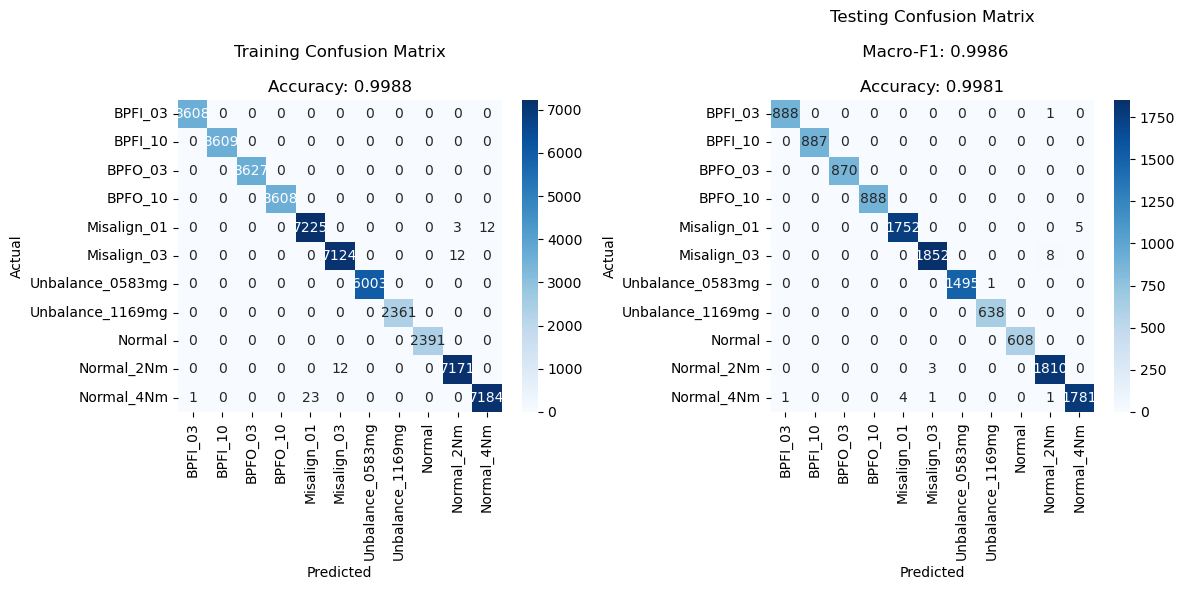

In [37]:
Fault_types = [ 'BPFI_03',
                'BPFI_10', 
                'BPFO_03', 
                'BPFO_10', 
                'Misalign_01', 
                'Misalign_03',
                'Unbalance_0583mg',
                'Unbalance_1169mg',
                'Normal',
                'Normal_2Nm',
                'Normal_4Nm',
                ]      
#Biểu đồ confusion matrix
plt.figure(figsize=(12, 6))# Kích thước biểu đồ
plt.subplot(1, 2, 1)# Vẽ biểu đồ đầu tiên trong 1 hàng 2 cột
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', 
xticklabels=Fault_types, yticklabels=Fault_types)# Vẽ heatmap với các nhãn trục x và y
plt.title(f'Training Confusion Matrix\n\nAccuracy: {train_accuracy:.4f}' )# Tiêu đề biểu đồ
plt.xlabel('Predicted')# Nhãn trục x
plt.ylabel('Actual')# Nhãn trục y
plt.subplot(1, 2, 2)# Vẽ biểu đồ thứ hai trong 1 hàng 2 cột
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
xticklabels=Fault_types, yticklabels=Fault_types)# Vẽ heatmap với các nhãn trục x và y
plt.title(f'Testing Confusion Matrix\n\n Macro-F1: {macro_f1:.4f}\n\nAccuracy: {test_accuracy:.4f}')# Tiêu đề biểu đồ
plt.xlabel('Predicted')# Nhãn trục x
plt.ylabel('Actual')# Nhãn trục y
plt.tight_layout()# Tự động điều chỉnh khoảng cách giữa các phần tử trong biểu đồ
plt.show()# Hiển thị biểu đồ


Bảng perclass recall

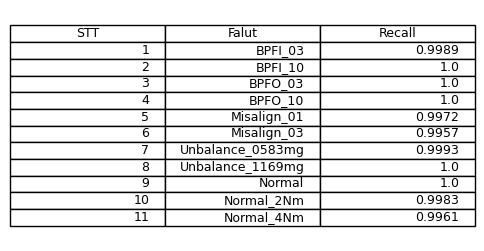

In [38]:
df_recall = pd.DataFrame({
    "STT": range(1, len(Fault_types) + 1),
    "Falut": Fault_types,
    "Recall": perclass_recall
})
# Vẽ bảng 
fig, ax = plt.subplots(figsize=(6, 3))  
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_recall.values, colLabels=df_recall.columns, loc='center')

plt.show()


In [39]:
x_train_df = pd.DataFrame(X_train_scale, columns=X.columns)
x_test_df = pd.DataFrame(X_test_scale, columns=X.columns)

Tạo explainer cho logistic model

In [40]:
Explainer = shap.Explainer(Best_model, x_train_df) # Tạo đối tượng giải thích mô hình
shap_values = Explainer(X_test_scale) # Tính giá trị SHAP cho tập kiểm tra

SHAP values for class: BPFI_03


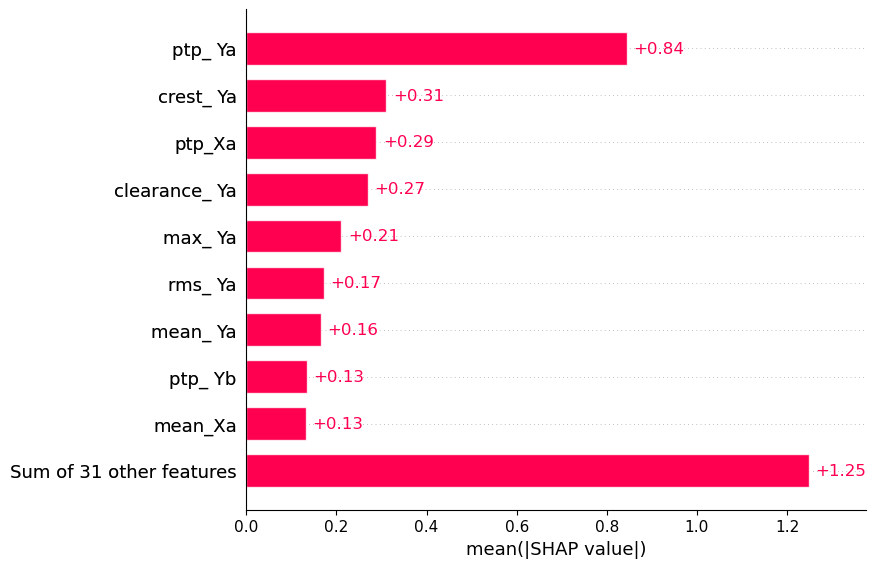

SHAP values for class: BPFI_10


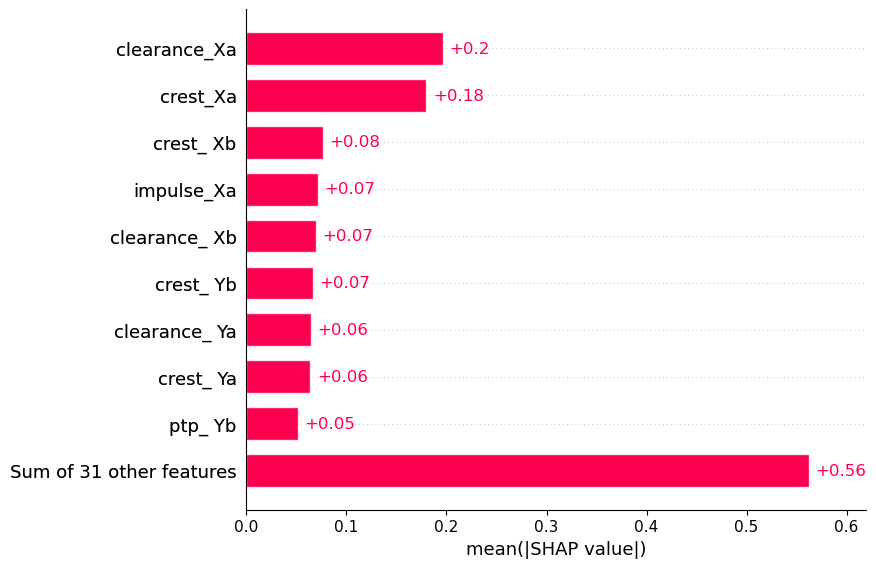

SHAP values for class: BPFO_03


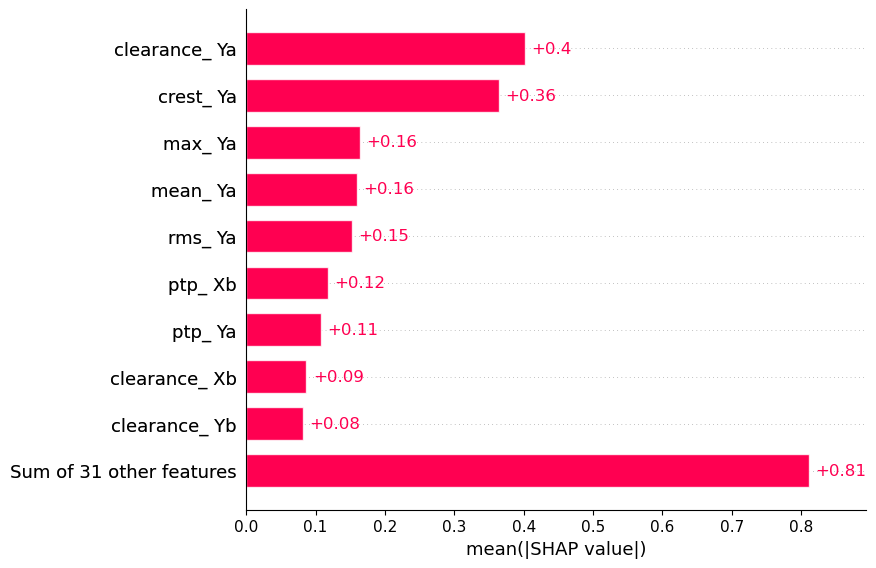

SHAP values for class: BPFO_10


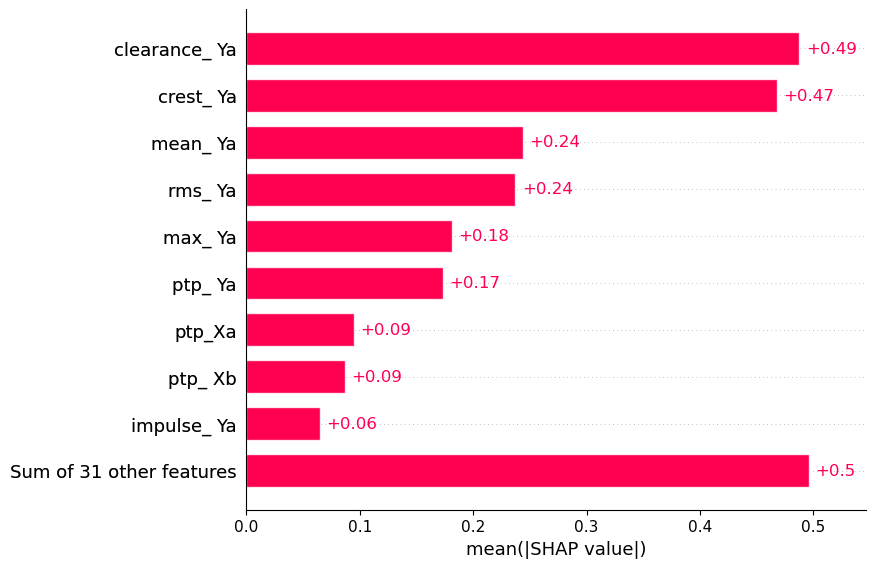

SHAP values for class: Misalign_01


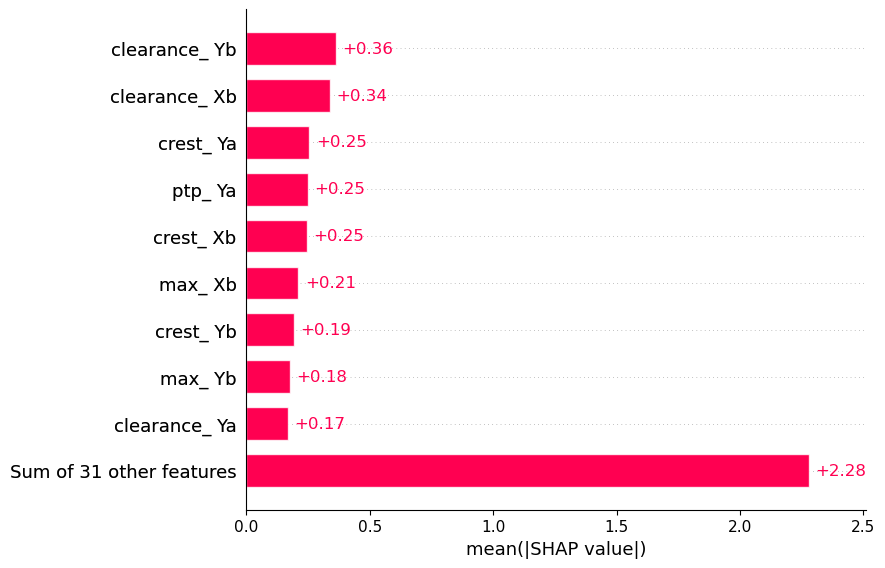

SHAP values for class: Misalign_03


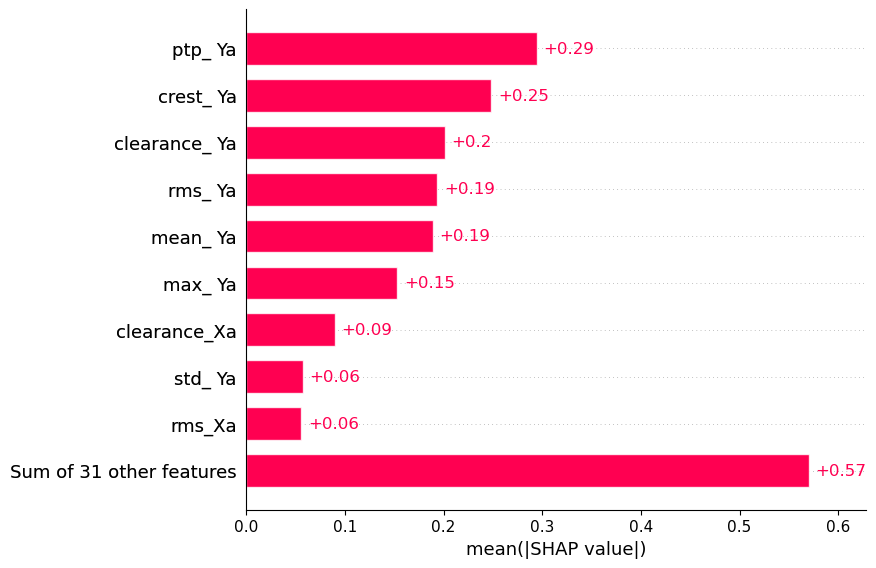

SHAP values for class: Unbalance_0583mg


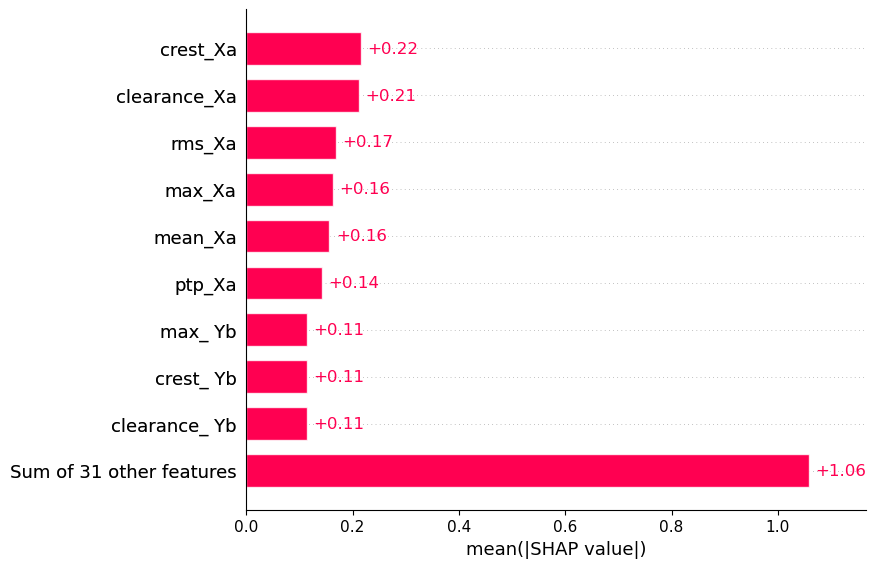

SHAP values for class: Unbalance_1169mg


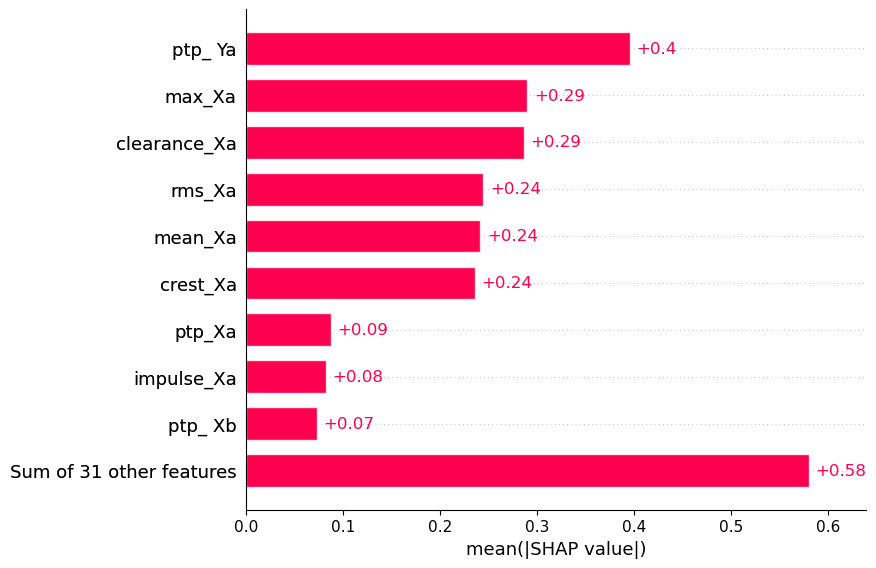

SHAP values for class: Normal


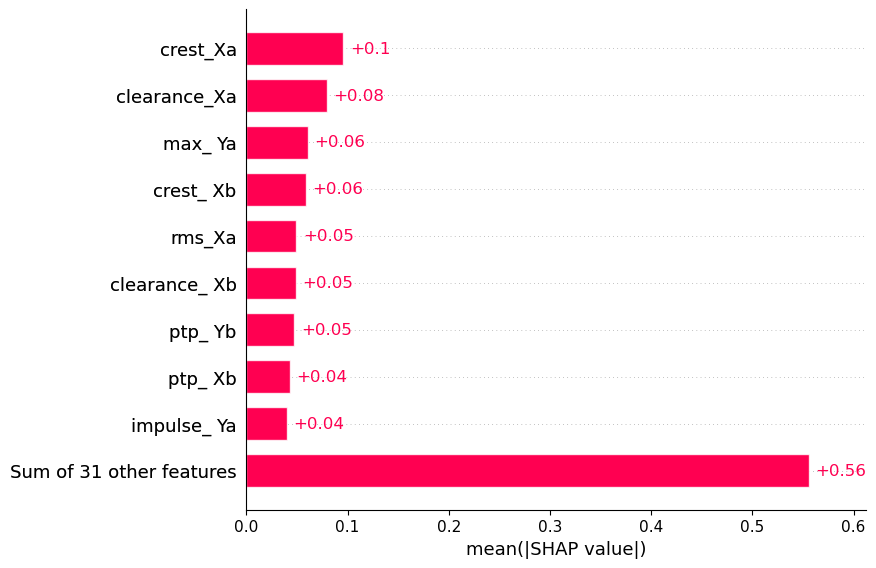

SHAP values for class: Normal_2Nm


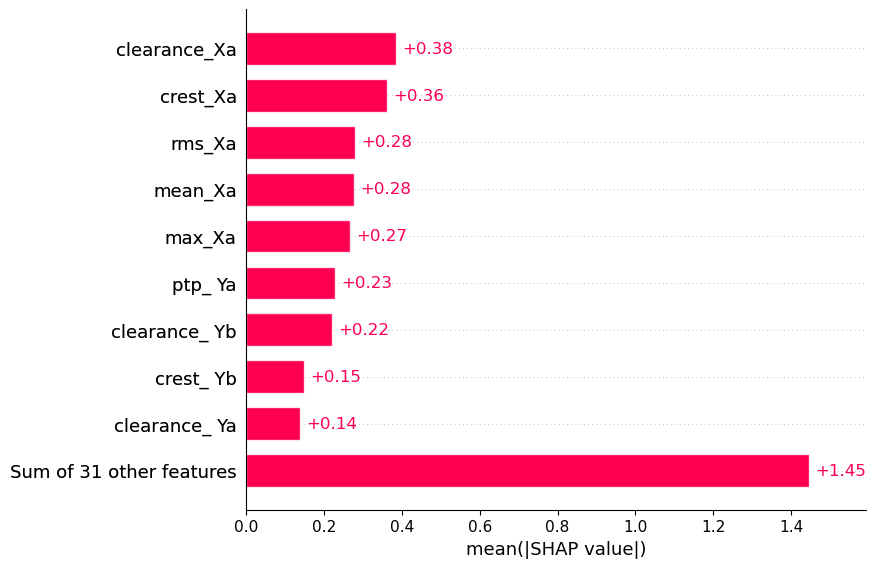

SHAP values for class: Normal_4Nm


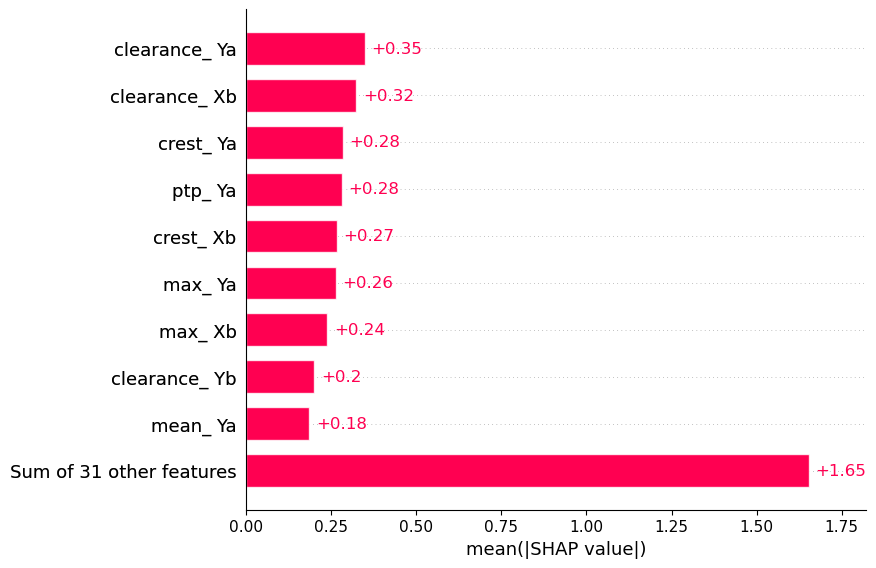

In [41]:
# Lấy tên feature từ file csv
feature_names = data.columns[:-1].tolist()   # bỏ cột 'label'
class_names   = data["label"].unique().tolist()

# Tạo explainer với feature_names
explainer = shap.Explainer(Best_model, X_train, feature_names=feature_names)
shap_values = explainer(X_test)

# Vẽ SHAP bar cho class thứ i
for i, cls in enumerate(class_names):
    print(f"SHAP values for class: {cls}")
    shap.plots.bar(shap_values[:, :, i], max_display=10)
